In [1]:
using ImmersedLayers
using Plots
using UnPack
using Interpolations
using ViscousStreaming

In [2]:
# markdown display disable
import Markdown
Base.showable(::MIME"text/markdown", ::Markdown.MD) = false

In [3]:
DDF_TYPE = CartesianGrids.Yang3

CartesianGrids.Yang3

set up exact solution

In [5]:
Re = 40
ϵ = 0.1
p = ViscousStreaming.StreamingParams(ϵ,Re)

Streaming flow parameters with Re = 40.0, ϵ = 0.1


In [6]:
sol_iner = ViscousStreaming.StreamingAnalytical(p, InertialFrame);

Maximum residual on W₁ = 5.684341886080802e-14
BC residual on Ψ₁(1) = 1.1443916996305594e-16
BC residual on dΨ₁(1) = 2.2887833992611187e-16
Maximum residual on Ws₂ = 3.979039320256561e-13
BC residual on Ψs₂(1) = 3.552713678800501e-15
BC residual on dΨs₂(1) = 2.6645352591003757e-15
Verifying second-order oscillatory solution...
Maximum residual on W₂ = 1.67181510390182e-12
BC residual on Ψ₂(1) = 2.8609792490763984e-17
BC residual on dΨ₂(1) = 2.220446049250313e-15


1st order solution

In [7]:
_get_helmholtz(coeff_factor::Real,α::Real,g::PhysicalGrid,with_inverse,::Type{IndexScaling}) =
               CartesianGrids.plan_helmholtz(g,with_inverse=with_inverse,factor=coeff_factor)
_get_helmholtz(coeff_factor::Real,α::Real,g::PhysicalGrid,with_inverse,::Type{GridScaling}) =
               CartesianGrids.plan_helmholtz(g,α*cellsize(g)^2,with_inverse=with_inverse,factor=coeff_factor/cellsize(g)^2)

_get_helmholtz (generic function with 2 methods)

In [8]:
function create_CHLinvCT(cache::BasicILMCache{N};scale=1.0) where {N}
    @unpack L, sdata_cache, gdata_cache, gcurl_cache = cache

    len = length(sdata_cache)
    A = Matrix{eltype(sdata_cache)}(undef,len,len)
    fill!(sdata_cache,0.0)

    for col in 1:len
        sdata_cache[col] = 1.0
        fill!(gdata_cache,0.0)
        fill!(gcurl_cache,0.0)

        surface_curl!(gcurl_cache,sdata_cache,cache)
        gcurl_cache .= H \ gcurl_cache
        inverse_laplacian!(gcurl_cache,cache)
        
        surface_curl!(sdata_cache,gcurl_cache,cache)

        A[:,col] = scale*sdata_cache
        fill!(sdata_cache,0.0)
    end

    return A

end

create_CHLinvCT (generic function with 1 method)

In [9]:
@ilmproblem ViscousStreaming vector

In [10]:
struct ViscousStreamingCache{SMT,SSMT,CMT,RCT,DVT,VNT,ST,VFT,FT} <: AbstractExtraILMCache
   S :: SMT
   Ss :: SSMT
   C :: CMT
   Rc :: RCT
   dv :: DVT
   vb :: DVT
   vprime :: DVT
   dvn :: VNT
   sstar :: ST
   vϕ :: VFT
   ϕ :: FT
end

In [11]:
function ImmersedLayers.prob_cache(prob::ViscousStreamingProblem,base_cache::BasicILMCache)
    S = create_CHLinvCT(base_cache)
    Ss = create_CLinvCT_scalar(base_cache)
    C = create_surface_filter(base_cache)

    dv = zeros_surface(base_cache)
    vb = zeros_surface(base_cache)
    vprime = zeros_surface(base_cache)

    dvn = ScalarData(dv)
    sstar = zeros_gridcurl(base_cache)
    vϕ = zeros_grid(base_cache)
    ϕ = Nodes(Primal,sstar)

    Rc = RegularizationMatrix(base_cache,dvn,ϕ)

    ViscousStreamingCache(S,Ss,C,Rc,dv,vb,vprime,dvn,sstar,vϕ,ϕ)
end

In [12]:
function ImmersedLayers.solve(prob::ViscousStreamingProblem,sys::ILMSystem)
    @unpack extra_cache, base_cache, bc, phys_params = sys
    @unpack nrm = base_cache
    @unpack S, Ss, C, Rc, dv, vb, vprime, sstar, dvn, vϕ, ϕ  = extra_cache

    Re = phys_params["Re"]
    #H = plan_helmholtz(vϕ, Re, with_inverse=true)

    σ = zeros_surface(sys)
    s = zeros_gridcurl(sys)
    v = zeros_grid(sys)

    # Get the jumps in velocity across surface
    prescribed_surface_jump!(dv,sys)

    # Compute ψ*
    surface_divergence_symm!(v,dv,sys)
    curl!(sstar,v,sys)
    #sstar .*= -1.0

    sstar .= H \ sstar
    inverse_laplacian!(sstar,sys) 
    #sstar .*= -1.0

    # Adjustment for jump in normal velocity
    pointwise_dot!(dvn,nrm,dv)
    regularize!(ϕ,dvn,Rc)
    inverse_laplacian!(ϕ,sys)
    grad!(vϕ,ϕ,sys)

    # Get the average velocity on the surface
    prescribed_surface_average!(vb,sys)
    ImmersedLayers.interpolate!(vprime,vϕ,sys)
    vprime .= vb - vprime # this is r2
    # reference frame correction
    # vprime.u .+= 1

    # Compute surface velocity due to ψ*
    curl!(v,sstar,sys)
    ImmersedLayers.interpolate!(vb,v,sys)

    # Spurious slip
    vprime .-= vb
    σ .= S\vprime

    # Correction streamfunction
    surface_curl!(s,σ,sys)
    #s .*= -1.0
    
    s .= H \ s
    inverse_laplacian!(s,sys)

    # Correct
    s .+= sstar

    # reference frame correction
    # s .-= y_gridcurl(sys)

    # Assemble the velocity
    curl!(v,s,sys)
    v .+= vϕ

    # Add the streamfunction equivalent to scalar potential
    ds = zeros_surfacescalar(base_cache)
    surface_grad_cross!(ds,ϕ,base_cache)
    ds .= Ss\ds
    surface_curl_cross!(sstar,ds,base_cache)
    sstar .*= -1.0
    inverse_laplacian!(sstar,base_cache)
    s .+= sstar

    # Filter the traction twice to clean it up a bit
    #σ .= C^2*σ

    return v, s, σ, sstar
end

In [13]:
spacing = 1.4 
Δx = 0.02
Lx = 5.98*2
xlim = (-Lx/2,Lx/2)
ylim = (-Lx/2,Lx/2)
g = PhysicalGrid(xlim,ylim,Δx;nthreads_max=4)
Δs = spacing*cellsize(g)
body = Circle(1.0, Δs)

Circular body with 224 points and radius 1.0
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


In [14]:
my_params = Dict()
my_params["Re"] = Re;

In [15]:
function get_vsplus1(base_cache,phys_params)
    vsplus = zeros_surface(base_cache)
    vsplus.u .= 1
    return vsplus
end
function get_vsminus1(base_cache,phys_params)
    vsminus = zeros_surface(base_cache)
    #vsminus.u .= 1
    return vsminus
end

bcdict1 = Dict("exterior"=>get_vsplus1,"interior"=>get_vsminus1);

In [16]:
α = 40
H = _get_helmholtz(1.0, α, g, true, GridScaling)

Discrete Helmholtz operator (and inverse) on a (nx = 600, ny = 600) grid with factor 2500.0 + 0.0im and spacing 1.0

In [17]:
prob1 = ViscousStreamingProblem(g,body,scaling=GridScaling,bc=bcdict1, dtype=ComplexF64, phys_params = my_params, ddftype=DDF_TYPE)
sys1 = construct_system(prob1);

In [18]:
@time v1, s1, σ1, sstar = ImmersedLayers.solve(prob1,sys1)
nothing

  2.262658 seconds (10.65 M allocations: 644.296 MiB, 2.54% gc time, 92.72% compilation time)


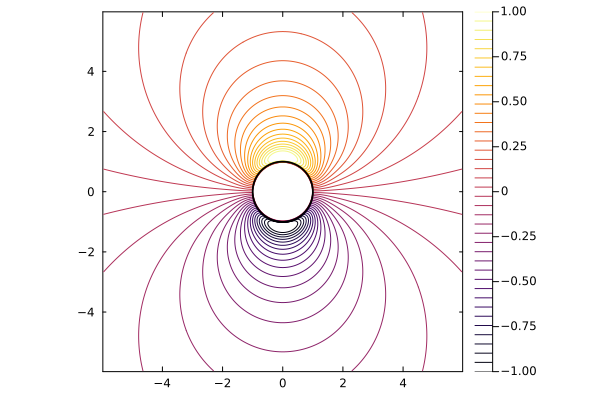

In [19]:
plot(real(s1),sys1, levels=range(-1,1,length=40),clim=(-1,1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=false)

compute nonlinear term

$vdw = \nabla \times (v_1 \cdot \nabla v_1)$

In [20]:
# need to use this version because I recalled a bug in original vdu, maybe I was wrong
# v.∇u, where v and u are both primal edge data
function _unscaled_convective_derivative!(vdu::Edges{Primal},v::Edges{Primal},u::Edges{Primal},extra_cache::ConvectiveDerivativeCache)
    @unpack vt1_cache, vt2_cache, vt3_cache = extra_cache

    fill!(vt1_cache,0.0)
    grid_interpolate!(vt1_cache,v)
    CartesianGrids.transpose!(vt2_cache,vt1_cache)
    fill!(vt1_cache,0.0)
    grad!(vt1_cache,u)
    product!(vt3_cache,vt2_cache,vt1_cache)
    fill!(vdu,0.0)
    grid_interpolate!(vdu,vt3_cache)
end

_unscaled_convective_derivative! (generic function with 1 method)

In [21]:
cdcache = ConvectiveDerivativeCache(sys1.base_cache)
vdv = zeros_grid(sys1)
_unscaled_convective_derivative!(vdv, v1, conj(v1), cdcache)
ImmersedLayers._scale_derivative!(vdv, sys1.base_cache)
vdw = zeros_gridcurl(sys1)
vdv =  1/2 * vdv;

# vdv .+= tract_field;

curl!(vdw, vdv, sys1);


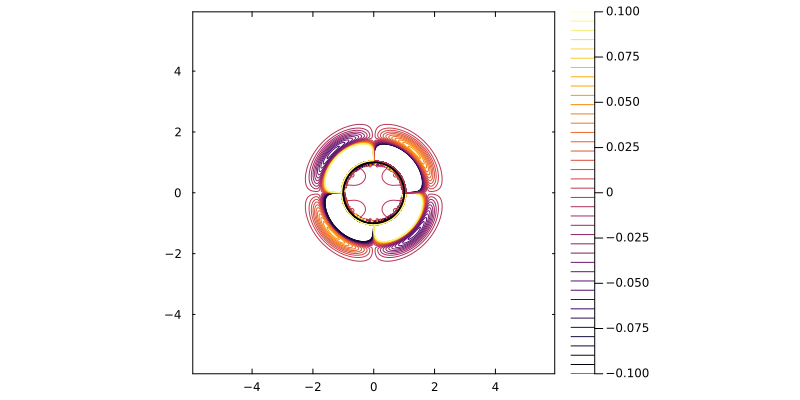

In [22]:
lim = 0.1
plot(real(vdw), sys1, levels=range(-lim,lim,length=40),clim=(-lim,lim), cbar=true, size = (800, 400), colorbar = true, fill = false)

In [ ]:
vdw_itp = interpolatable_field(real(vdw), sys1);

r_test = 0.8:Δx:1.2
offset = 30
plot(r_test, vdw_itp.(r_test.*cos((45-offset)*π/180), r_test .*sin((45-offset)*π/180)))
plot!(r_test, vdw_itp.(r_test.*cos((45+offset)*π/180), r_test .*sin((45+offset)*π/180)),ylim=(-100,100))

In [26]:
ud = similar(v1)
ud .= imag(vdv);

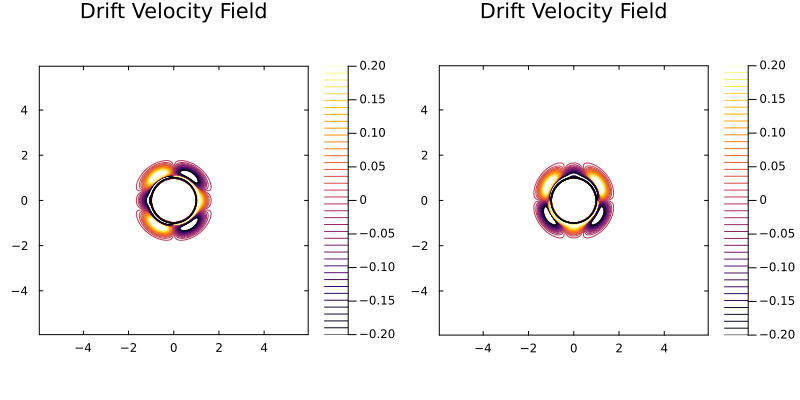

In [28]:
lim = 0.2
plot(real(ud), sys1, levels=range(-lim,lim,length=40),clim=(-lim,lim), cbar=true, size = (800, 400), colorbar = true, fill = false)
title!("Drift Velocity Field")

In [37]:
fb_exact = zeros_surface(sys1)
xf = sys1.base_cache.pts.u
yf = sys1.base_cache.pts.v;
fb_exact.u .= [ViscousStreaming.uvelocity(x, y, 0.0, sol_iner.s2s) for (x, y) in zip(xf, yf)]
fb_exact.v .= [ViscousStreaming.vvelocity(x, y, 0.0, sol_iner.s2s) for (x, y) in zip(xf, yf)];

2nd order solution

In [29]:
@ilmproblem ViscousStreaming2 vector

In [30]:
struct ViscousStreaming2Cache{SMT,SSMT,CMT,RCT,DVT,VNT,ST,VFT,FT} <: AbstractExtraILMCache
   S :: SMT
   Ss :: SSMT
   C :: CMT
   Rc :: RCT
   dv :: DVT
   vb :: DVT
   vprime :: DVT
   dvn :: VNT
   sstar :: ST
   vϕ :: VFT
   ϕ :: FT
end

In [31]:
function ImmersedLayers.prob_cache(prob::ViscousStreaming2Problem,base_cache::BasicILMCache)
    S = create_CL2invCT(base_cache)
    Ss = create_CLinvCT_scalar(base_cache)
    C = create_surface_filter(base_cache)

    dv = zeros_surface(base_cache)
    vb = zeros_surface(base_cache)
    vprime = zeros_surface(base_cache)

    dvn = ScalarData(dv)
    sstar = zeros_gridcurl(base_cache)
    vϕ = zeros_grid(base_cache)
    ϕ = Nodes(Primal,sstar)

    Rc = RegularizationMatrix(base_cache,dvn,ϕ)

    ViscousStreaming2Cache(S,Ss,C,Rc,dv,vb,vprime,dvn,sstar,vϕ,ϕ)
end

In [ ]:
function ImmersedLayers.solve(prob::ViscousStreaming2Problem,sys::ILMSystem)
    @unpack extra_cache, base_cache, bc, phys_params = sys
    @unpack nrm = base_cache
    @unpack S, Ss, C, Rc, dv, vb, vprime, sstar, dvn, vϕ, ϕ  = extra_cache

    Re = phys_params["Re"]

    σ = zeros_surface(sys)
    s = zeros_gridcurl(sys)
    v = zeros_grid(sys)

    # Get the jumps in velocity across surface
    prescribed_surface_jump!(dv,sys)

    # Compute ψ*
    surface_divergence_symm!(v,dv,sys)
    curl!(sstar,v,sys)
    sstar .*= -1.0

    # where forcing term is used
    ##=============================
    ##=============================
    sstar .-= Re * real(vdw)
    # sstar .-= Re * real(n1)
    ##=============================
    ##============================= 

    inverse_laplacian!(sstar,sys)
    inverse_laplacian!(sstar,sys)

    # Adjustment for jump in normal velocity
    pointwise_dot!(dvn,nrm,dv)
    regularize!(ϕ,dvn,Rc)
    inverse_laplacian!(ϕ,sys)
    grad!(vϕ,ϕ,sys)

    # Get the average velocity on the surface
    prescribed_surface_average!(vb,sys)
    ImmersedLayers.interpolate!(vprime,vϕ,sys)
    vprime .= vb #- vprime
    # reference frame correction
    # vprime.u .+= 1

    # Compute surface velocity due to ψ*
    #curl!(v,sstar,sys)
    #ImmersedLayers.interpolate!(vb,v,sys)
    surface_curl!(vb,sstar,sys)

    # Spurious slip
    vprime .-= vb
    σ .= S\vprime

    # Correction streamfunction
    surface_curl!(s,σ,sys)
    s .*= -1.0
    inverse_laplacian!(s,sys)
    inverse_laplacian!(s,sys)

    # Correct
    s .+= sstar

    # reference frame correction
    # s .-= y_gridcurl(sys)

    # Assemble the velocity
    curl!(v,s,sys)
    #v .+= vϕ

    # Add the streamfunction equivalent to scalar potential
    #=
    ds = zeros_surfacescalar(base_cache)
    surface_grad_cross!(ds,ϕ,base_cache)
    ds .= Ss\ds
    surface_curl_cross!(sstar,ds,base_cache)
    sstar .*= -1.0
    inverse_laplacian!(sstar,base_cache)
    s .+= sstar # should be +
    =#

    # Filter the traction twice to clean it up a bit
    σ .= C^2*σ

    return v, s, σ, sstar, vϕ
end

In [50]:
fake_factor = 1

function get_vsplus2(base_cache,phys_params)
    vsplus = zeros_surface(base_cache)
    vsplus.u .= fake_factor * real(fb_exact.u)
    vsplus.v .= fake_factor * real(fb_exact.v)
    return vsplus
end
function get_vsminus2(base_cache,phys_params)
    vsminus = zeros_surface(base_cache)
    # vsminus.u .= fake_factor * real(fb_exact.u)
    # vsminus.v .= fake_factor * real(fb_exact.v)
    return vsminus
end

bcdict2 = Dict("exterior"=>get_vsplus2,"interior"=>get_vsminus2);

In [39]:
prob2 = ViscousStreaming2Problem(g,body,scaling=GridScaling,bc=bcdict2, phys_params = my_params, ddftype=DDF_TYPE)
sys2 = construct_system(prob2);

In [51]:
@time v2, s2, σ2, sstar2, vϕ2 = ImmersedLayers.solve(prob2,sys2)
nothing

  0.146692 seconds (6.81 k allocations: 91.340 MiB, 37.59% gc time, 10.24% compilation time)


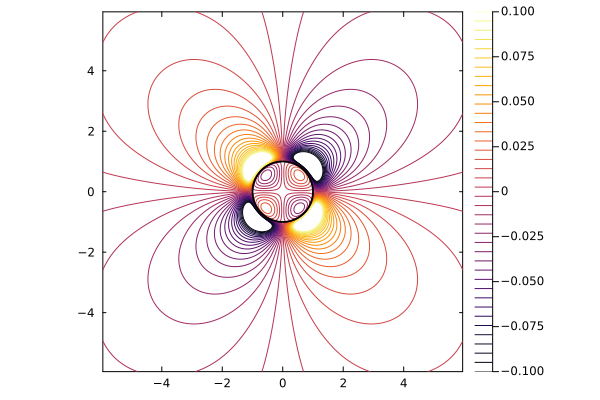

In [52]:
lim = 0.1
plot(s2, sys2, colorbar = true, aspect_ratio=:equal, bodyfill=false, levels=range(-lim, lim, length=40), clim=(-lim, lim))
# xlims!(0, Lx/2)
# ylims!(0, Lx/2)